In [1]:
import numpy as np
import xarray as xr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.colors as mcolors

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
import cartopy.feature as cfeature


from pylab import rcParams
rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'normal'

In [2]:


def plot_with_regression(ax, x, y, x_label, y_label, years, highlight_years=[], volc_years=[]):
    x = np.asarray(x)
    y = np.asarray(y)
    years = np.asarray(years)
    
    # Fit regression
    model = LinearRegression()
    model.fit(x.reshape(-1, 1), y)
    y_pred = model.predict(x.reshape(-1, 1))
    r2 = r2_score(y, y_pred)

    # Base scatter
    ax.scatter(x, y, c='lightgrey', s=40, label='_base')

    # Color palette for highlighted years
    color_palette = sns.color_palette("colorblind", len(highlight_years))
    year_color_map = dict(zip(highlight_years, color_palette))

    # Plot highlighted years and their previous years
    for i, yr in enumerate(highlight_years):
        idx = np.where(years == yr)[0][0]
        ax.scatter(x[idx], y[idx], color=year_color_map[yr], s=80, label=str(yr), zorder=3)

        # Mark the previous year
        prev_year = yr - 1
        if prev_year in years:
            prev_idx = np.where(years == prev_year)[0][0]
            ax.scatter(x[prev_idx], y[prev_idx], 
                       facecolor='lightgrey', edgecolor=year_color_map[yr], 
                       linewidth=2, s=60, zorder=2)

    # Highlight 2023
    if 2023 in years:
        idx_2023 = np.where(years == 2023)[0][0]
        idx_2022 = np.where(years == 2022)[0][0]

        # Plot 2023
        ax.scatter(x[idx_2023], y[idx_2023], c='black', s=80, label='2023', zorder=4)

        # Plot 2022
        ax.scatter(x[idx_2022], y[idx_2022], facecolor='lightgrey', edgecolor='black',
                   linewidth=2, s=60, label='2022/Year [-1]', zorder=4)

        # Draw arrow from 2022 to 2023
        ax.annotate(
            '',
            xy=(x[idx_2023], y[idx_2023]),
            xytext=(x[idx_2022], y[idx_2022]),
            arrowprops=dict(
                arrowstyle='->,head_length=2,head_width=1',  # smaller head
                linestyle='solid',#(0, (1, 5)),  
                color='black',
                lw=1.2  # slightly thinner
            ),
            zorder=3
        )


    # Volcanic years (black x)
    for j, volc_year in enumerate(volc_years):
        if volc_year in years:
            idx_volc = np.where(years == volc_year)[0][0]
            ax.scatter(x[idx_volc], y[idx_volc], c='black', s=100, marker='x', linewidths=2.0,
                       label='Volcanic' if j == 0 else None, zorder=1)

    # Regression line
    ax.plot(np.sort(x), np.sort(y_pred), color='dimgrey', linestyle='--', label=f'$R^2 = {r2:.2f}$')

    # Zero lines
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5)

    # Aesthetic cleanup
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Labels
    ax.set_xlabel(x_label, fontsize=20)
    ax.set_ylabel(y_label, fontsize=20)
    ax.tick_params(labelsize=14)
    ax.legend()

    print(r2)
    return y - y_pred  # residuals


### Panel a

In [6]:
t500 = xr.open_dataset('../preprocessed_data/fig4a.nc')


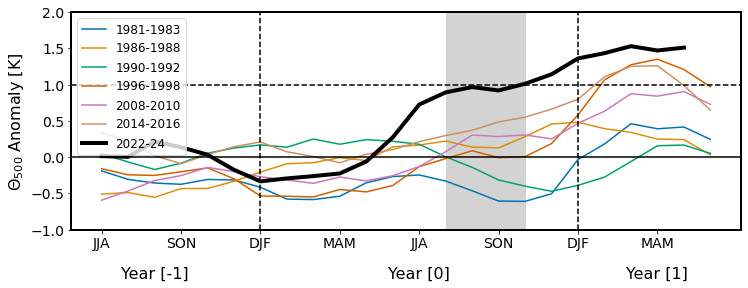

In [8]:

# Define event years
c_years = [1982, 1987, 1991, 1997, 2009,  2015]

# Get a nice color palette (e.g., Set2, colorblind, Paired)
colors = sns.color_palette("colorblind", len(c_years))  # Try "colorblind", "Set1", or "tab10"

fig, ax = plt.subplots(1, 1, figsize=(12, 4), sharey=True)

# Loop through historical years with better colors
for i, c in enumerate(c_years):
    ds_sel = t500.sel(time=slice(f"{c-1}-07", f"{c+1}-06"))
    ax.plot(np.arange(ds_sel.time.shape[0]), ds_sel.anom, label=f"{c-1}-{c+1}", color=colors[i])

# Recent period in black, thicker line
ds_sel = t500.sel(time=slice("2022-07", "2024-06"))
ax.plot(np.arange(ds_sel.time.shape[0]), ds_sel.anom, label="2022-24", color="k", linewidth=4)



#graphical stuff
# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['JJA', 'SON', 'DJF', 'MAM', 'JJA', 'SON', 'DJF', 'MAM']  # Representative months



ax.axhline(0, c = 'k')
ax.axhline(1, c = 'k', linestyle = '--')
ax.axhline(-1, c = 'k', linestyle = '--')
ax.axhline(2, c = 'k', linestyle = ':')
ax.axhline(-2, c = 'k', linestyle = ':')

ax.fill_between(x = [13,16], y1 = 3, y2 = -3, color = 'lightgrey' )


ax.set_ylabel(r'$\Theta_{500}$ Anomaly [K]', fontsize = 16, fontweight = 'normal')
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, fontsize =16)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_ylim(-1, 2)


ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

    # Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

    # Second row: Manually add every 8th label slightly lower
for i in [2,12,21]:
    ax.text(i, -1.5, f"Year [{i//10 -1}]", ha="center", va="top", fontsize=16, color="black",
            fontweight ='normal')




ax.legend(fontsize= 12, loc = 'upper left')

### Panel b-e

In [23]:
## Load Data
fig4_ts = xr.open_dataset("../preprocessed_data/fig4_ts.nc")

pws_aso = xr.Dataset({"pws_detrended": fig4_ts["pws_aso"]})
t500_aso = xr.Dataset({"t500_detrended": fig4_ts["t500_aso"]})
t2m_aso = xr.Dataset({"t2m_detrended": fig4_ts["t2m_aso"]})

fig4_fields = xr.open_dataset("../preprocessed_data/fig4_fields.nc")

corr = fig4_fields["corr"]
pval = fig4_fields["pval"]
corr_GSAT = fig4_fields["corr_GSAT"]
pval_GSAT = fig4_fields["pval_GSAT"]


#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-90,90))
ocean_mask = masks.seamask # mask for all contintnets


### Panel b

0.6728025455178688


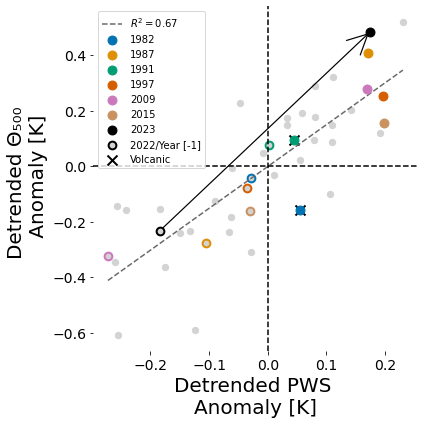

In [18]:
highlight_years = [1982, 1987, 1991, 1997, 2009, 2015]
volcanic_years = [1982, 1991]

fig, ax = plt.subplots(figsize=(6, 6))

residuals = plot_with_regression(
    ax,
    x=pws_aso.pws_detrended.values,
    y=t500_aso.t500_detrended,
    x_label='Detrended PWS \nAnomaly [K]',
    y_label = 'Detrended Θ₅₀₀ \n Anomaly [K]',
    years=pws_aso.year.values,
    highlight_years=highlight_years,
    volc_years=volcanic_years
)

plt.tight_layout()
plt.show()

### Panel c

0.6114378510895484


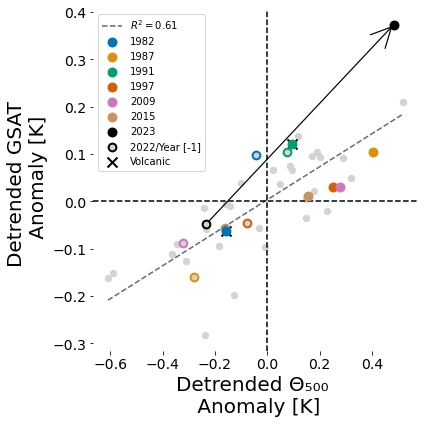

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))

residuals = plot_with_regression(
    ax,
    x=t500_aso.t500_detrended,
    y=t2m_aso.t2m_detrended,
    x_label='Detrended Θ₅₀₀ \n Anomaly [K]',
    y_label = 'Detrended GSAT \n Anomaly [K]',
    years=t500_aso.year.values,
    highlight_years=highlight_years,
    volc_years=volcanic_years
)

plt.tight_layout()
plt.show()

### Panel d

/tmp/ipykernel_1922197/804518340.py:40: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


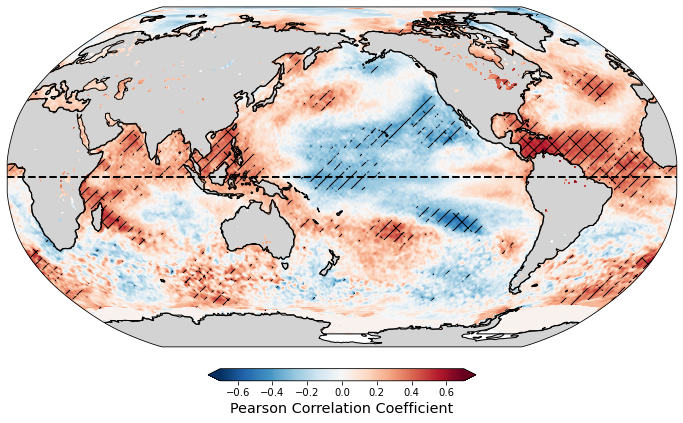

In [25]:
# Define projection
projection = ccrs.Robinson(central_longitude=180)

# Create figure and axis
fig, ax = plt.subplots(subplot_kw={'projection': projection}, figsize=(12, 8))

# Plot correlation using pcolormesh
cbar = ax.pcolormesh(corr.lon, corr.lat, corr, cmap='RdBu_r', transform=ccrs.PlateCarree(), shading='auto', vmin=-.7, vmax=.7)

# Add colorbar
cb = plt.colorbar(cbar, ax=ax, orientation='horizontal', shrink=0.4, pad=0.05, extend='both')
cb.set_label('Pearson Correlation Coefficient')

# Add hatching for p < 0.05
sig_mask_005 = pval < 0.05
ax.contourf(corr.lon, corr.lat, sig_mask_005, levels=[0.5, 1.5],
            hatches=['//'], colors='none', transform=ccrs.PlateCarree())

# Add hatching for p < 0.01
sig_mask_001 = pval < 0.01
ax.contourf(corr.lon, corr.lat, sig_mask_001, levels=[0.5, 1.5],
            hatches=['\\'], colors='none', transform=ccrs.PlateCarree())

# Add coastlines and land
ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')

# Add ocean contour
ax.contour(ocean_mask.lon, ocean_mask.lat, ocean_mask,
           levels=[0.5], colors='black', linewidths=1, transform=ccrs.PlateCarree())

# Add equator line
ax.axhline(0, linewidth=2, c='k', linestyle='--')

# Remove gridlines and axis decorations
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('')

plt.tight_layout()
plt.show()

### Panel e

/tmp/ipykernel_1922197/3363143559.py:40: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


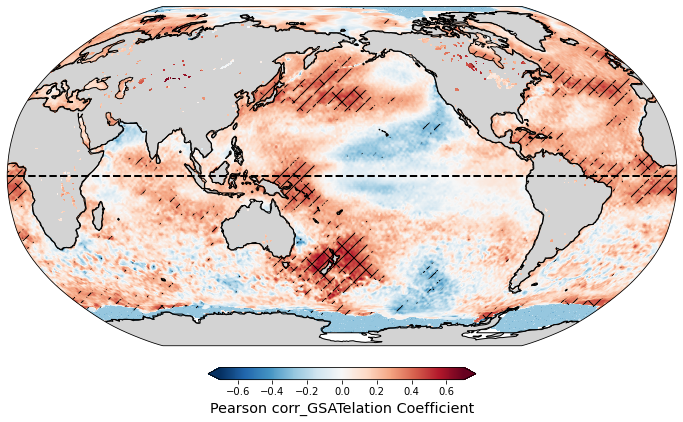

In [26]:
# Define projection
projection = ccrs.Robinson(central_longitude=180)

# Create figure and axis
fig, ax = plt.subplots(subplot_kw={'projection': projection}, figsize=(12, 8))

# Plot corr_GSATelation using pcolormesh
cbar = ax.pcolormesh(corr_GSAT.lon, corr_GSAT.lat, corr_GSAT, cmap='RdBu_r', transform=ccrs.PlateCarree(), shading='auto', vmin=-.7, vmax=.7)

# Add colorbar
cb = plt.colorbar(cbar, ax=ax, orientation='horizontal', shrink=0.4, pad=0.05, extend='both')
cb.set_label('Pearson corr_GSATelation Coefficient')

# Add hatching for p < 0.05
sig_mask_005 = pval_GSAT < 0.05
ax.contourf(corr_GSAT.lon, corr_GSAT.lat, sig_mask_005, levels=[0.5, 1.5],
            hatches=['//'], colors='none', transform=ccrs.PlateCarree())

# Add hatching for p < 0.01
sig_mask_001 = pval_GSAT < 0.01
ax.contourf(corr_GSAT.lon, corr_GSAT.lat, sig_mask_001, levels=[0.5, 1.5],
            hatches=['\\'], colors='none', transform=ccrs.PlateCarree())

# Add coastlines and land
ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')

# Add ocean contour
ax.contour(ocean_mask.lon, ocean_mask.lat, ocean_mask,
           levels=[0.5], colors='black', linewidths=1, transform=ccrs.PlateCarree())

# Add equator line
ax.axhline(0, linewidth=2, c='k', linestyle='--')

# Remove gridlines and axis decorations
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('')

plt.tight_layout()
plt.show()
